# BIRCH - Instacart (extended)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    birch_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../extended_datasets/instacart_model_extended.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 11


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
0,-0.286895,-0.070348,-0.578158,-1.227829,0.699419,0.241265,-0.990167,-1.002478,-1.009504,1.238152,-1.238152
1,1.212334,0.316791,0.820566,0.729024,0.322297,0.371165,0.903750,0.454433,0.572875,0.210583,-0.210583
2,-0.568000,0.138171,-0.236083,-0.814629,-0.427875,-1.032762,-0.338142,-0.660110,-0.482044,0.908586,-0.908586
3,1.212334,-0.826933,-1.313020,-0.833881,0.134288,0.741993,-1.050748,-0.825157,-0.482044,-1.775655,1.775655
4,-1.036509,-1.054508,0.139108,-0.260001,-0.769372,-0.728977,-0.728409,-0.660110,-0.482044,-0.253936,0.253936


## Evaluación del número de clusters


In [3]:
resultados_birch = birch_metrics(X)
display(resultados_birch)

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but M

,k,silhouette,calinski_harabasz,davies_bouldin,n_clusters_found,tiempo_segundos
0,2,0.276127,99217.888911,1.373578,2,7.749034
1,3,0.257285,82731.087165,1.412483,3,6.431987
2,4,0.221993,73062.643685,1.372656,4,6.375497
3,5,0.185406,59703.394248,1.627117,5,6.395463
4,6,0.186733,60524.252246,1.443126,6,6.390419
5,7,0.176165,56235.942104,1.455110,7,6.383619
6,8,0.172147,52283.999475,1.466804,8,6.425420
7,9,0.169918,47678.099909,1.626222,9,6.442759
8,10,0.166615,45242.854704,1.533485,10,6.395664


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_birch,
    model_name="birch",
    dataset_name="instacart",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

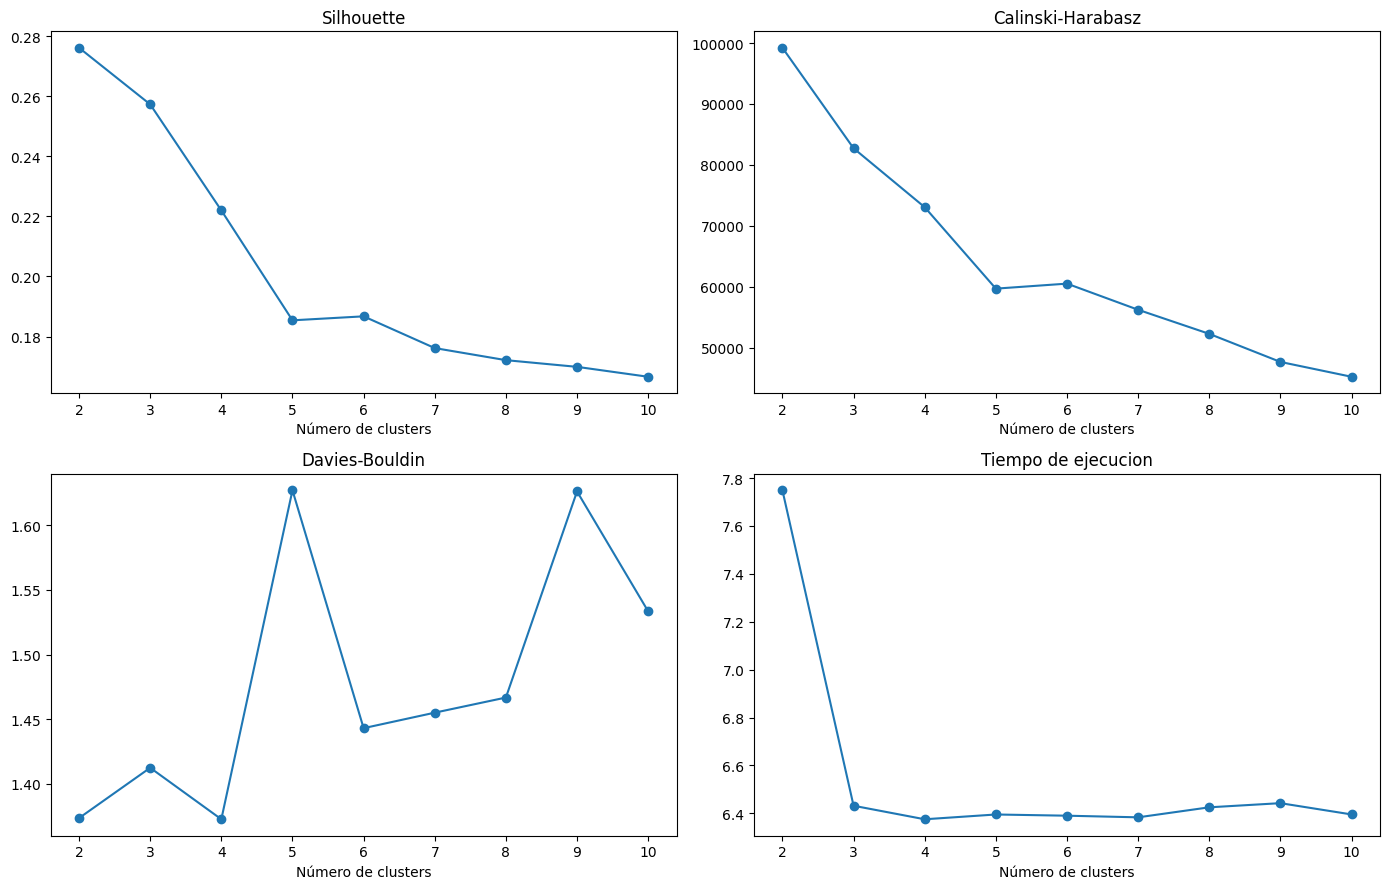

In [4]:
plot_clustering_metrics(
    resultados_birch,
    fourth_metric="tiempo_segundos",
    fourth_title="Tiempo de ejecución",
)

## Ajuste final y perfil de los clusters


In [ ]:
modelo, labels = fit_clustering_model(
    model_name="birch",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


cluster
0    100135
1    106074
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    48.56
1    51.44
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
cluster,,,,,,,,,,,
0,21.248,6.610,7.375,3.166,16.044,11.453,27.637,16.121,8.202,0.318,0.682
1,13.110,24.068,12.384,5.305,10.960,7.615,99.370,38.794,13.307,0.540,0.460


- Cluster 0 - Clientes ocasionales y exploratorios (48,56%): tienen mayor recencia, baja frecuencia y cestas pequeñas. Compran menos productos, pasillos y departamentos y presentan una recompra reducida; su mayor ratio de variedad indica menor repetición dentro de un volumen de compra limitado.
- Cluster 1 - Clientes frecuentes y recurrentes (51,44%): compran más recientemente y con mucha mayor frecuencia, realizan cestas grandes y acceden a una variedad absoluta muy superior. Su elevada tasa de recompra refleja hábitos consolidados y una fuerte vinculación con la plataforma.